# Small / Medium / Large Genre Expansion Report

This notebook answers two related questions:

1. For each top genre present in the **exact small** dataset, are there any rows that exist in the **cumulative medium** dataset but not in the **exact small** dataset?
2. Which top genres are found in the **exact large** dataset but not in the **exact medium** dataset?

Interpretation used here:
- **exact small dataset** = rows whose exact FMA subset label is `small`
- **cumulative medium dataset** = rows from `small ∪ medium`
- **medium but not small** = rows in the cumulative medium dataset whose `track_id` is not present in the exact small subset
- **exact medium dataset** = rows whose exact FMA subset label is `medium`
- **exact large dataset** = rows whose exact FMA subset label is `large`
- **large but not medium** = genres that appear in exact large but do not appear in exact medium

The output includes:
- a per-genre summary table for genres present in exact small
- a detailed list of matching medium-only rows
- a report of genres that appear in cumulative medium but not in exact small at all
- a report of genres that appear in exact large but not in exact medium at all
- quick plots for inspection

In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display

TRACKS_CSV = "../../FMA/fma_metadata/tracks.csv"
TOP_N_GENRES = None  # set to an integer like 10 to keep only the top-N genres in the displayed reports

In [38]:
tracks = pd.read_csv(TRACKS_CSV, header=[0, 1], index_col=0)
tracks.index.name = "track_id"

df = tracks[[
    ("set", "subset"),
    ("set", "split"),
    ("track", "genre_top"),
    ("track", "duration"),
    ("artist", "id"),
]].copy()
df.columns = ["subset", "split", "genre_top", "duration_s", "artist_id"]

small_exact = df[(df["subset"] == "small") & df["genre_top"].notna()].copy()
medium_exact = df[(df["subset"] == "medium") & df["genre_top"].notna()].copy()
large_exact = df[(df["subset"] == "large") & df["genre_top"].notna()].copy()
medium_cumulative = df[df["subset"].isin(["small", "medium"]) & df["genre_top"].notna()].copy()
large_cumulative = df[df["subset"].isin(["small", "medium", "large"]) & df["genre_top"].notna()].copy()

medium_only = medium_cumulative.loc[~medium_cumulative.index.isin(small_exact.index)].copy()

print(f"Exact small labeled rows              : {len(small_exact):,}")
print(f"Exact medium labeled rows             : {len(medium_exact):,}")
print(f"Exact large labeled rows              : {len(large_exact):,}")
print(f"Cumulative medium labeled rows        : {len(medium_cumulative):,}")
print(f"Cumulative large labeled rows         : {len(large_cumulative):,}")
print(f"Medium-only labeled rows vs small     : {len(medium_only):,}")

Exact small labeled rows              : 8,000
Exact medium labeled rows             : 17,000
Exact large labeled rows              : 24,598
Cumulative medium labeled rows        : 25,000
Cumulative large labeled rows         : 49,598
Medium-only labeled rows vs small     : 17,000


In [39]:
small_genre_counts = small_exact["genre_top"].value_counts().sort_values(ascending=False)
if TOP_N_GENRES is not None:
    small_genres = small_genre_counts.head(TOP_N_GENRES).index.tolist()
else:
    small_genres = small_genre_counts.index.tolist()

report_rows = []
detailed_rows = []

for genre in small_genres:
    small_rows = small_exact[small_exact["genre_top"] == genre].copy()
    medium_only_rows = medium_only[medium_only["genre_top"] == genre].copy()

    report_rows.append({
        "genre_top": genre,
        "small_count": int(len(small_rows)),
        "medium_only_count": int(len(medium_only_rows)),
        "found_in_medium_not_small": bool(len(medium_only_rows) > 0),
        "sample_medium_only_track_ids": medium_only_rows.index.astype(int).tolist()[:10],
    })

    if len(medium_only_rows) > 0:
        tmp = medium_only_rows.copy().reset_index()
        tmp.insert(1, "source_genre_from_small_rank", small_genres.index(genre) + 1)
        detailed_rows.append(tmp)

report_df = pd.DataFrame(report_rows)
report_df["small_rank"] = np.arange(1, len(report_df) + 1)
report_df = report_df[[
    "small_rank",
    "genre_top",
    "small_count",
    "medium_only_count",
    "found_in_medium_not_small",
    "sample_medium_only_track_ids",
]]

detailed_report_df = (
    pd.concat(detailed_rows, ignore_index=True)
    if detailed_rows else pd.DataFrame(columns=["track_id", "source_genre_from_small_rank", "subset", "split", "genre_top", "duration_s", "artist_id"])
)

# View 1: genres that exist in cumulative medium but do not appear in exact small at all.
medium_only_genre_counts = medium_only["genre_top"].value_counts().sort_values(ascending=False)
new_medium_genre_counts = medium_only_genre_counts.loc[
    ~medium_only_genre_counts.index.isin(small_genre_counts.index)
]
medium_new_genres_df = new_medium_genre_counts.rename("medium_only_count").reset_index()
medium_new_genres_df.columns = ["genre_top", "medium_only_count"]
medium_new_genres_df.insert(0, "medium_only_genre_rank", np.arange(1, len(medium_new_genres_df) + 1))

# View 2: genres that exist in exact large but do not appear in exact medium at all.
medium_exact_genre_counts = medium_exact["genre_top"].value_counts().sort_values(ascending=False)
large_exact_genre_counts = large_exact["genre_top"].value_counts().sort_values(ascending=False)
new_large_genre_counts = large_exact_genre_counts.loc[
    ~large_exact_genre_counts.index.isin(medium_exact_genre_counts.index)
]
large_new_genres_df = new_large_genre_counts.rename("large_count").reset_index()
large_new_genres_df.columns = ["genre_top", "large_count"]
large_new_genres_df.insert(0, "large_genre_rank", np.arange(1, len(large_new_genres_df) + 1))

print("Per-genre summary for genres present in exact small:")
display(report_df)

print()
print("Genres from exact small with at least one medium-only row:")
display(report_df[report_df["found_in_medium_not_small"]].reset_index(drop=True))

print()
print("Top genres found in cumulative medium but not in exact small, with counts:")
if medium_new_genres_df.empty:
    print("No additional genres were found in medium beyond the genres already present in exact small.")
else:
    display(medium_new_genres_df)

print()
print("Top genres found in exact large but not in exact medium, with counts:")
if large_new_genres_df.empty:
    print("No additional genres were found in exact large beyond the genres already present in exact medium.")
else:
    display(large_new_genres_df)
    print()
    print(f"Found {len(large_new_genres_df):,} genres that appear in exact large but not in exact medium.")

Per-genre summary for genres present in exact small:


,small_rank,genre_top,small_count,medium_only_count,found_in_medium_not_small,sample_medium_only_track_ids
0,1,Hip-Hop,1000,1201,True,"[3, 134, 583, 584, 585, 668, 669, 672, 673, 674]"
1,2,Pop,1000,186,True,"[823, 1652, 3536, 5178, 5196, 11257, 11259, 13..."
2,3,Folk,1000,519,True,"[139, 198, 208, 209, 535, 536, 537, 603, 619, ..."
3,4,Experimental,1000,1251,True,"[425, 819, 820, 854, 868, 898, 1068, 1071, 107..."
4,5,Rock,1000,6103,True,"[136, 181, 247, 249, 257, 258, 341, 343, 352, ..."
5,6,International,1000,18,True,"[18045, 24744, 51997, 54477, 54478, 59668, 596..."
6,7,Electronic,1000,5314,True,"[397, 398, 399, 400, 405, 414, 550, 664, 665, ..."
7,8,Instrumental,1000,350,True,"[10230, 10231, 10234, 10239, 10240, 10243, 102..."



Genres from exact small with at least one medium-only row:


,small_rank,genre_top,small_count,medium_only_count,found_in_medium_not_small,sample_medium_only_track_ids
0,1,Hip-Hop,1000,1201,True,"[3, 134, 583, 584, 585, 668, 669, 672, 673, 674]"
1,2,Pop,1000,186,True,"[823, 1652, 3536, 5178, 5196, 11257, 11259, 13..."
2,3,Folk,1000,519,True,"[139, 198, 208, 209, 535, 536, 537, 603, 619, ..."
3,4,Experimental,1000,1251,True,"[425, 819, 820, 854, 868, 898, 1068, 1071, 107..."
4,5,Rock,1000,6103,True,"[136, 181, 247, 249, 257, 258, 341, 343, 352, ..."
5,6,International,1000,18,True,"[18045, 24744, 51997, 54477, 54478, 59668, 596..."
6,7,Electronic,1000,5314,True,"[397, 398, 399, 400, 405, 414, 550, 664, 665, ..."
7,8,Instrumental,1000,350,True,"[10230, 10231, 10234, 10239, 10240, 10243, 102..."



Top genres found in cumulative medium but not in exact small, with counts:


,medium_only_genre_rank,genre_top,medium_only_count
0,1,Classical,619
1,2,Old-Time / Historic,510
2,3,Jazz,384
3,4,Country,178
4,5,Soul-RnB,154
5,6,Spoken,118
6,7,Blues,74
7,8,Easy Listening,21



Top genres found in exact large but not in exact medium, with counts:
No additional genres were found in exact large beyond the genres already present in exact medium.


In [40]:
if detailed_report_df.empty:
    print("No medium-only rows were found for the selected small-dataset genres.")
else:
    print(f"Detailed report rows: {len(detailed_report_df):,}")
    display(detailed_report_df.sort_values(["genre_top", "track_id"]).reset_index(drop=True))

Detailed report rows: 14,942


,track_id,source_genre_from_small_rank,subset,split,genre_top,duration_s,artist_id
0,397,7,medium,training,Electronic,240,90
1,398,7,medium,training,Electronic,344,90
2,399,7,medium,training,Electronic,388,90
3,400,7,medium,training,Electronic,395,90
4,405,7,medium,training,Electronic,439,90
...,...,...,...,...,...,...,...
14937,154450,5,medium,training,Rock,293,24257
14938,154656,5,medium,training,Rock,259,24286
14939,154747,5,medium,training,Rock,133,24224
14940,154853,5,medium,training,Rock,150,17344


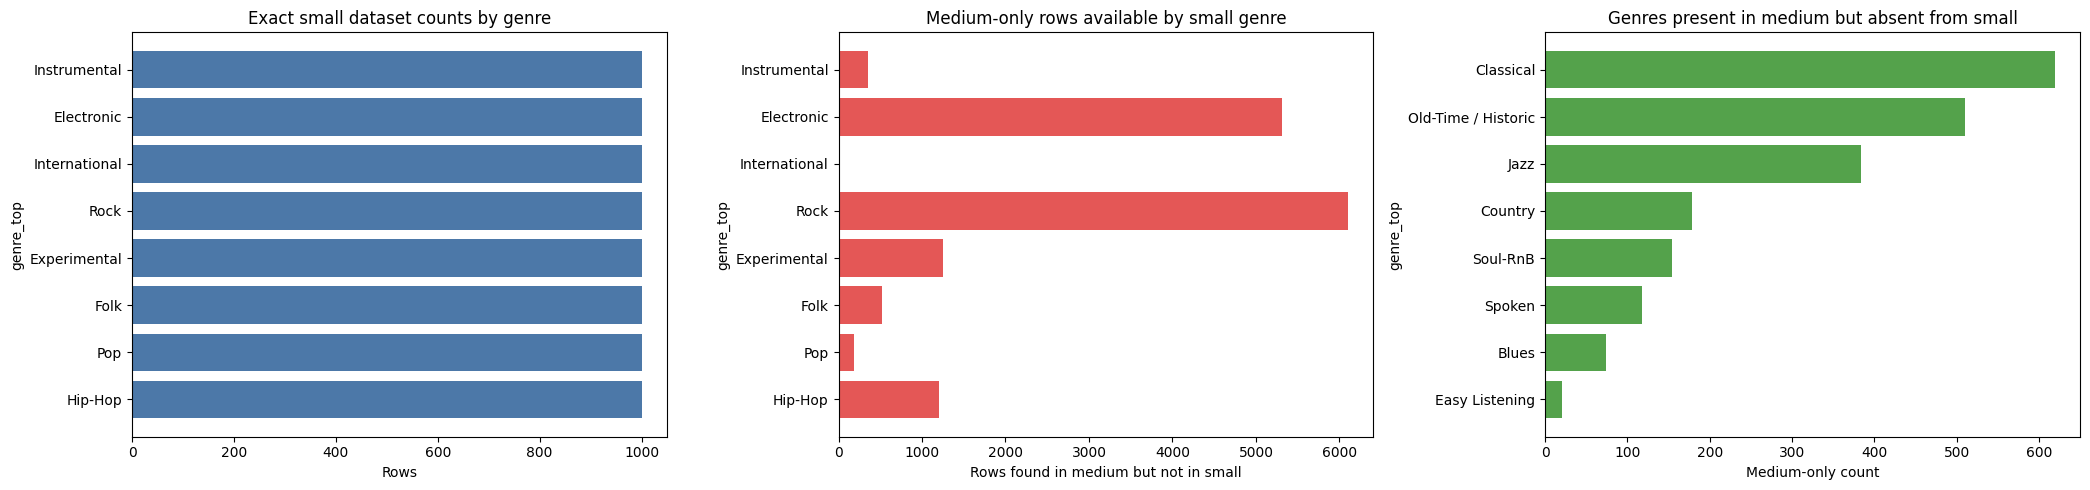

In [41]:
plot_df = report_df.copy()
plot_df = plot_df.sort_values("small_count", ascending=True)

has_new_medium_genres = not medium_new_genres_df.empty
has_new_large_genres = not large_new_genres_df.empty
ncols = 2 + int(has_new_medium_genres) + int(has_new_large_genres)
fig, axes = plt.subplots(1, ncols, figsize=(7 * ncols, max(5, 0.45 * len(plot_df))))
axes = np.atleast_1d(axes)

axes[0].barh(plot_df["genre_top"], plot_df["small_count"], color="#4C78A8")
axes[0].set_title("Exact small dataset counts by genre")
axes[0].set_xlabel("Rows")
axes[0].set_ylabel("genre_top")

colors = ["#E45756" if x > 0 else "#BAB0AC" for x in plot_df["medium_only_count"]]
axes[1].barh(plot_df["genre_top"], plot_df["medium_only_count"], color=colors)
axes[1].set_title("Medium-only rows available by small genre")
axes[1].set_xlabel("Rows found in medium but not in small")
axes[1].set_ylabel("genre_top")

plot_col = 2
if has_new_medium_genres:
    new_plot_df = medium_new_genres_df.copy().sort_values("medium_only_count", ascending=True)
    axes[plot_col].barh(new_plot_df["genre_top"], new_plot_df["medium_only_count"], color="#54A24B")
    axes[plot_col].set_title("Genres present in medium but absent from small")
    axes[plot_col].set_xlabel("Medium-only count")
    axes[plot_col].set_ylabel("genre_top")
    plot_col += 1

if has_new_large_genres:
    large_plot_df = large_new_genres_df.copy().sort_values("large_count", ascending=True)
    axes[plot_col].barh(large_plot_df["genre_top"], large_plot_df["large_count"], color="#B279A2")
    axes[plot_col].set_title("Genres present in exact large but absent from exact medium")
    axes[plot_col].set_xlabel("Large count")
    axes[plot_col].set_ylabel("genre_top")

plt.tight_layout()
plt.show()

In [42]:
# Optional: save the reports next to the notebook or elsewhere if needed
# report_df.to_csv("small_vs_medium_genre_summary.csv", index=False)
# detailed_report_df.to_csv("small_vs_medium_genre_detailed_rows.csv", index=False)
# medium_new_genres_df.to_csv("medium_not_in_small_genres.csv", index=False)
# large_new_genres_df.to_csv("exact_large_not_in_exact_medium_genres.csv", index=False)

summary_stats = {
    "genres_checked": int(len(report_df)),
    "genres_with_medium_only_rows": int(report_df["found_in_medium_not_small"].sum()),
    "total_medium_only_rows_for_small_genres": int(report_df["medium_only_count"].sum()),
    "new_genres_in_medium_not_in_small": int(len(medium_new_genres_df)),
    "new_genres_in_exact_large_not_in_exact_medium": int(len(large_new_genres_df)),
}

print("Summary stats:")
for key, value in summary_stats.items():
    print(f"- {key}: {value:,}")

Summary stats:
- genres_checked: 8
- genres_with_medium_only_rows: 8
- total_medium_only_rows_for_small_genres: 14,942
- new_genres_in_medium_not_in_small: 8
- new_genres_in_exact_large_not_in_exact_medium: 0
